# Bagging Models

target = `Irrigation_Need` (Low / Medium / High)

**Models:** BaggingClassifier, Random Forest, Extra Trees  
**Metric:** Weighted F1 (class imbalance: High = 3.3%)

## 1. Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED=42; 
TARGET='Irrigation_Need'; 
ORDER=['Low','Medium','High']
CAT_COLS=['Soil_Type','Crop_Type','Crop_Growth_Stage','Season',
          'Irrigation_Type','Water_Source','Mulching_Used','Region']

## 2. Load Data & Feature Engineering

In [ ]:
# load training and test datasets
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# Feature engineering from EDA findings
for df in [train, test]:
    # create a new categorical feature by combining two existing categorical columns
    df['stage_mulch'] = df['Crop_Growth_Stage'].astype(str) + '_' + df['Mulching_Used'].astype(str)

    # create a stress index (higher temp + wind, lower moisture → higher stress)
    df['stress_index'] = (df['Temperature_C'] + df['Wind_Speed_kmh']) / (df['Soil_Moisture'] + 1)

    # create a water deficit feature (higher temp and lower rainfall → higher deficit)
    df['water_deficit'] = df['Temperature_C'] / (df['Rainfall_mm'] / 100 + 1)

FEAT_CATS = CAT_COLS + ['stage_mulch']
# list of categorical features (original + new combined feature)

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
# create encoder that converts categories to numbers, handling unseen values as -1

train[FEAT_CATS] = oe.fit_transform(train[FEAT_CATS])
# fit encoder on training data and transform it

test[FEAT_CATS]  = oe.transform(test[FEAT_CATS])
# apply same transformation to test data

le = LabelEncoder()
# create encoder for target variable

y = le.fit_transform(train[TARGET])
# convert target labels into numeric values

print('Class encoding:', dict(zip(le.classes_, le.transform(le.classes_))))
# print mapping from original class names to numbers

FEAT_COLS = [c for c in train.columns if c not in ['id', TARGET]]
# select all feature columns (exclude id and target)

X = train[FEAT_COLS].values
X_test = test[FEAT_COLS].values
# convert features to numpy arrays for modeling

print(f'Total features: {len(FEAT_COLS)}')
# print number of features

print(FEAT_COLS)
# print list of feature names

Class encoding: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Total features: 22
['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'stage_mulch', 'stress_index', 'water_deficit']


## 3. Cross-Validation Setup

In [5]:
CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

# Work on 30K sample for CV speed, all models validated same way for fair comparison
sample_idx = np.random.RandomState(SEED).choice(len(X), 30000, replace=False)
X_s, y_s = X[sample_idx], y[sample_idx]
print(f'Tuning sample: {len(X_s):,} rows')
print('3-fold stratified CV configured (n_jobs=1 for reproducibility)')

Tuning sample: 30,000 rows
3-fold stratified CV configured (n_jobs=1 for reproducibility)


## 4. Model 1: BaggingClassifier
From lecture notes:
Bootstrap sampling and aggregation of decision trees. Each tree sees a random 80% of rows and 80% of features.  
Class imbalance handled by passing `class_weight='balanced'` to the base DecisionTree.

In [6]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(class_weight='balanced'),
    n_estimators=100, max_samples=0.8, max_features=0.8,
    bootstrap=True, n_jobs=1, random_state=SEED
)
s = cross_val_score(bag, X_s, y_s, cv=CV, scoring='f1_weighted', n_jobs=1)
print(f'BaggingClassifier  CV weighted F1: {s.mean():.4f} +/- {s.std():.4f}')

BaggingClassifier  CV weighted F1: 0.9799 +/- 0.0005


## 5. Model 2: Random Forest
Extends bagging with feature randomness, only sqrt(n_features) features considered at each split, maybe reduced variance   
`class_weight='balanced'` automatically adjusts weights

In [7]:
# Try different depths
for depth in [10, 20, None]:
    rf_t = RandomForestClassifier(n_estimators=100, max_depth=depth,
                                   class_weight='balanced', n_jobs=1, random_state=SEED)
    s = cross_val_score(rf_t, X_s, y_s, cv=CV, scoring='f1_weighted', n_jobs=1)
    print(f'  max_depth={str(depth):5s}: {s.mean():.4f} +/- {s.std():.4f}')

  max_depth=10   : 0.9712 +/- 0.0011
  max_depth=20   : 0.9803 +/- 0.0009
  max_depth=None : 0.9801 +/- 0.0007


In [8]:
rf = RandomForestClassifier(n_estimators=200, max_depth=None,
                             class_weight='balanced', n_jobs=1, random_state=SEED)
s = cross_val_score(rf, X_s, y_s, cv=CV, scoring='f1_weighted', n_jobs=1)
m_rf, s_rf = s.mean(), s.std()
print(f'Random Forest      CV weighted F1: {m_rf:.4f} +/- {s_rf:.4f}')

Random Forest      CV weighted F1: 0.9808 +/- 0.0008


## 6. Model 3: ExtraTreesClassifier
from notes:
Extra Trees uses the **entire training set** (no bootstrap) with **random split thresholds** instead of optimal ones. This adds more randomness, which can reduce overfitting on clean datasets.  

In [9]:
et = ExtraTreesClassifier(n_estimators=100, class_weight='balanced',
                           n_jobs=1, random_state=SEED)
s = cross_val_score(et, X_s, y_s, cv=CV, scoring='f1_weighted', n_jobs=1)
m_et, s_et = s.mean(), s.std()
print(f'Extra Trees        CV weighted F1: {m_et:.4f} +/- {s_et:.4f}')
print()
print('Note: ET lower than RF here because random splits are suboptimal on rule-like synthetic data.')

Extra Trees        CV weighted F1: 0.9465 +/- 0.0007

Note: ET lower than RF here because random splits are suboptimal on rule-like synthetic data.


## 7. Model Comparison

BaggingClassifier        : 0.9799 +/- 0.0005
Random Forest            : 0.9808 +/- 0.0008
Extra Trees              : 0.9465 +/- 0.0007


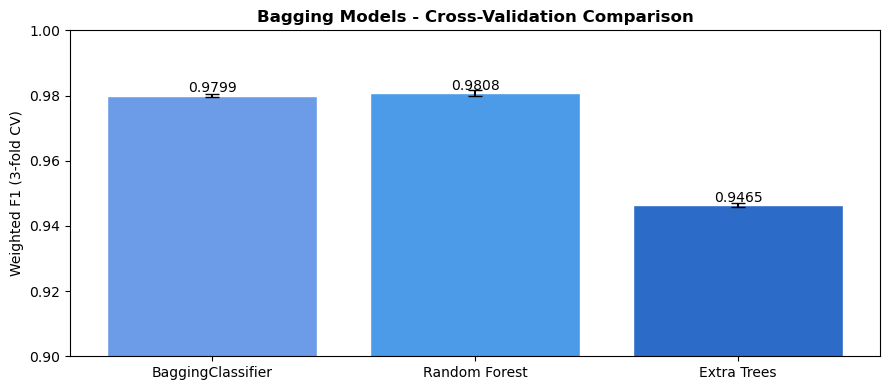

In [11]:
from sklearn.model_selection import cross_val_score

models = {
    'BaggingClassifier': bag,
    'Random Forest':     rf,
    'Extra Trees':       et,
}

bagging_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_s, y_s, cv=CV, scoring='f1_weighted', n_jobs=1)
    bagging_results[name] = (scores.mean(), scores.std())
    print(f'{name:25s}: {scores.mean():.4f} +/- {scores.std():.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
names = list(bagging_results.keys())
means = [bagging_results[n][0] for n in names]
stds  = [bagging_results[n][1] for n in names]
bars = ax.bar(names, means, yerr=stds, capsize=5,
              color=['#6C9BE8','#4C9BE8','#2C6BC8'], edgecolor='white')
ax.set_ylim(0.90, 1.00); ax.set_ylabel('Weighted F1 (3-fold CV)')
ax.set_title('Bagging Models - Cross-Validation Comparison', fontweight='bold')
for bar, val in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001, f'{val:.4f}', ha='center', fontsize=10)
plt.tight_layout(); plt.show()

## 8. Best Model further testing, seeing performance

In [12]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(X_s, y_s, test_size=0.2,
                                              stratify=y_s, random_state=SEED)
rf.fit(X_tr, y_tr)
y_pred = rf.predict(X_val)

print(classification_report(y_val, y_pred, target_names=le.classes_))
print(f'Weighted F1 : {f1_score(y_val, y_pred, average="weighted"):.4f}')
print(f'Macro   F1  : {f1_score(y_val, y_pred, average="macro"):.4f}')

              precision    recall  f1-score   support

        High       0.96      0.87      0.92       205
         Low       0.98      0.99      0.99      3505
      Medium       0.98      0.97      0.97      2290

    accuracy                           0.98      6000
   macro avg       0.97      0.95      0.96      6000
weighted avg       0.98      0.98      0.98      6000

Weighted F1 : 0.9797
Macro   F1  : 0.9589


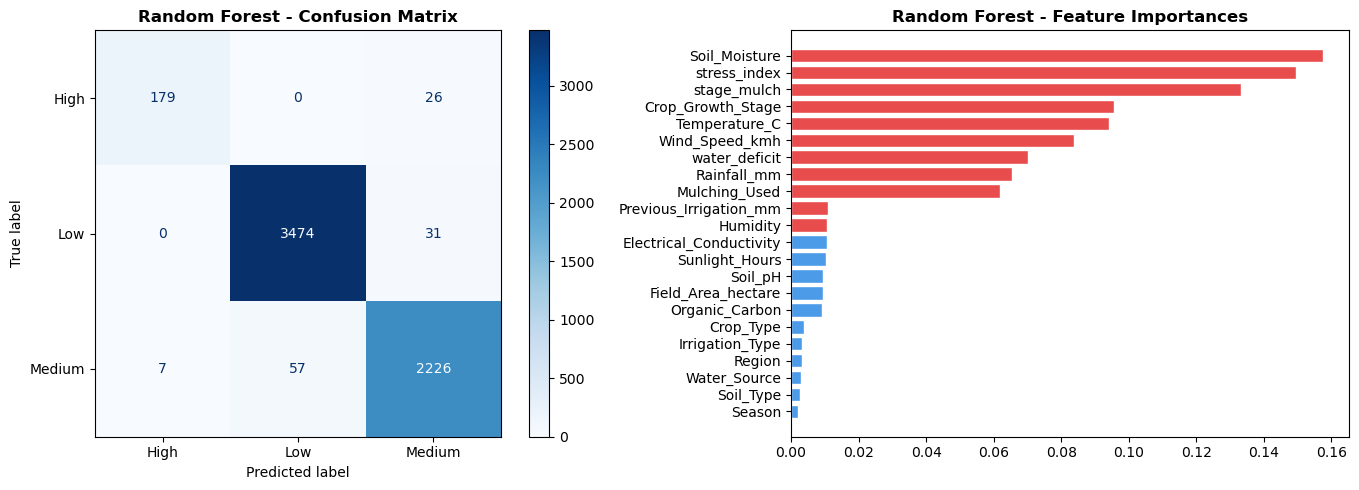

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(confusion_matrix(y_val, y_pred), display_labels=le.classes_).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Random Forest - Confusion Matrix', fontweight='bold')

imp = pd.Series(rf.feature_importances_, index=FEAT_COLS).sort_values()
c = ['#E84C4C' if v > imp.median() else '#4C9BE8' for v in imp]
axes[1].barh(imp.index, imp.values, color=c, edgecolor='white')
axes[1].set_title('Random Forest - Feature Importances', fontweight='bold')
plt.tight_layout(); plt.show()

## 9. Kaggle Submission (Bagging)

In [14]:
# Fit on 200K sample (memory/time constraint; use full data on Kaggle)
full_idx = np.random.RandomState(SEED).choice(len(X), 200000, replace=False)
rf_sub = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                 n_jobs=1, random_state=SEED)
rf_sub.fit(X[full_idx], y[full_idx])

submission = pd.DataFrame({'id': test['id'],
                            TARGET: le.inverse_transform(rf_sub.predict(X_test))})
submission.to_csv('submission_bagging.csv', index=False)
print('Saved: submission_bagging.csv')
print(submission[TARGET].value_counts())

Saved: submission_bagging.csv
Irrigation_Need
Low       159838
Medium    101728
High        8434
Name: count, dtype: int64
